## Transfer Learning with TensorFlow - Scaling Up

#### In this notebook we're going to scale up from using 10 classes of the [Food101](https://www.kaggle.com/datasets/dansbecker/food-101) dataset to using all (i.e., 101) of the classes in the dataset.  The Food101 dataset consists of 1000 images per class (750 of each class in the training set and 250 of each class in the test set), totalling 101000 images. And we're going to train the model on only 10% of the data  using transfer learning!

#### Preliminaries

In [ ]:
!nvidia-smi

Thu Mar  6 23:55:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import tensorflow as tf

print(tf.__version__)

2.18.0


Download the `helper_functions.py` script...

In [ ]:
!wget https://raw.githubusercontent.com/ROARMarketingConcepts/Tensorflow-Deep-Learning/refs/heads/main/extras/helper_functions.py

--2025-03-06 23:55:31--  https://raw.githubusercontent.com/ROARMarketingConcepts/Tensorflow-Deep-Learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0.001s  

2025-03-06 23:55:31 (15.0 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [ ]:
from helper_functions import *

#### We will leverage pre-trained models in `tf.keras.applications` to apply to image classification use cases.

#### Let's get the data...

In [ ]:
# Get 10% of the data of the 10 classes
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip

# Unzip the data
unzip_data("101_food_classes_10_percent.zip")

--2025-03-06 23:55:36--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.141.207, 74.125.137.207, 142.250.101.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.141.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip’

101_food_classes_10 100%[===================>]   1.51G   225MB/s    in 13s     

2025-03-06 23:55:49 (120 MB/s) - ‘101_food_classes_10_percent.zip’ saved [1625420029/1625420029]



In [ ]:
walk_through_dir("101_food_classes_10_percent")

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/test'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/miso_soup'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/garlic_bread'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/hot_dog'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/pancakes'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/macaroni_and_cheese'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/cheesecake'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/poutine'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/club_sandwich'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/beef_carpaccio'.
There are 0 directories and 250 images in

Now we've got some image data, we need a way of loading it into a TensorFlow compatible format.

Previously, we've used the `ImageDataGenerator` class. However, as of August 2023, this class is deprecated and isn't recommended for future usage (it's too slow). Because of this, we'll move onto using `tf.keras.utils.image_dataset_from_directory()`.

This method expects image data in the following file format:

`main_directory/`

`...class_a/`

`......a_image_1.jpg`

`......a_image_2.jpg`

`...class_b/`

`......b_image_1.jpg`

`......b_image_2.jpg`



In [ ]:
# Setup data inputs

train_dir = "101_food_classes_10_percent/train/"
test_dir = "101_food_classes_10_percent/test/"

IMG_SIZE = (224, 224) # define image size

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                            image_size=IMG_SIZE,
                                                                            label_mode="categorical", # what type are the labels?
                                                                            batch_size=32) # batch_size is 32 by default, this is generally a good number

test_data_100_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                           image_size=IMG_SIZE,
                                                                           label_mode="categorical")

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


In [ ]:
train_data_10_percent

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.float32, name=None))>

In [ ]:
train_data_10_percent.class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

In [ ]:
# See an example batch of data.  Notice that the labels are OneHotEncoded!

for images, labels in train_data_10_percent.take(1):
  print(images, labels)

tf.Tensor(
[[[[1.41989792e+02 1.37989792e+02 1.26989799e+02]
   [1.38530609e+02 1.34530609e+02 1.23530609e+02]
   [1.43739792e+02 1.39739792e+02 1.28525513e+02]
   ...
   [7.59389114e+01 7.55001526e+01 4.50817909e+01]
   [7.54999237e+01 7.85713654e+01 5.16223946e+01]
   [6.54438324e+01 7.02142487e+01 4.67550926e+01]]

  [[1.45382660e+02 1.41382660e+02 1.29382660e+02]
   [1.45423477e+02 1.41423477e+02 1.29423477e+02]
   [1.38127548e+02 1.34127548e+02 1.22127548e+02]
   ...
   [7.11736221e+01 7.09440536e+01 4.32450676e+01]
   [7.99540482e+01 8.29489594e+01 5.62959213e+01]
   [7.23519287e+01 7.62600937e+01 5.13060112e+01]]

  [[1.44979599e+02 1.41765305e+02 1.27408165e+02]
   [1.45918365e+02 1.42704086e+02 1.28346939e+02]
   [1.41775513e+02 1.38392868e+02 1.24540817e+02]
   ...
   [6.82754822e+01 6.73979416e+01 4.59693451e+01]
   [7.75408630e+01 7.79694366e+01 5.39694366e+01]
   [7.54997940e+01 7.69233551e+01 5.09947510e+01]]

  ...

  [[1.15443916e+02 1.17290855e+02 1.05938797e+02]
   [1

#### ModelCheckPoint

Recall that the `ModelCheckpoint` callback gives us the ability to save the model, as a whole in the `SavedModel` format or the weights (patterns) only to a specified directory as it trains.

For example, say we fit a feature extraction transfer learning model for 5 epochs and we check the training curves and see it was still improving and we want to see if fine-tuning for another 5 epochs could help, we can load the checkpoint, unfreeze some (or all) of the base model layers and then continue training.

Let's create a `ModelCheckpoint` callback. To do so, we have to specify a directory to which we would like to save.

In [ ]:
# Setup checkpoint path
checkpoint_path = "101_classes_model_checkpoints_weights/.weights.h5" # note: remember saving directly to Colab is temporary

# Create a ModelCheckpoint callback that saves the model's weights only
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                         save_weights_only=True, # set to False to save the entire model
                                                         save_best_only=True, # save only the best model weights instead of a model every epoch
                                                         save_freq="epoch", # save every epoch
                                                         verbose=1)

Checkpoint ready. Now let's create a small data augmentation model with the Sequential API. Because we're working with a reduced sized training set, this will help prevent our model from overfitting on the training data.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# from tensorflow.keras.layers.experimental import preprocessing

# NEW: Newer versions of TensorFlow (2.10+) can use the tensorflow.keras.layers API directly for data augmentation
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomHeight(0.2),
  layers.RandomWidth(0.2),
  # preprocessing.Rescaling(1./255) # keep for ResNet50V2, remove for EfficientNetV2B0
  ], name ="data_augmentation")

#### Build the first model, `model`.

In [ ]:
# Set up input shape and base model, freezing the base model layers
input_shape = (224, 224, 3)
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False

# Create input layer
inputs = layers.Input(shape=input_shape, name="input_layer")

# Add in data augmentation Sequential model as a layer
x = data_augmentation(inputs)

# Give base_model inputs (after augmentation) and don't train it
x = base_model(x, training=False)

# Pool output features of base model
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

# Put a dense layer on as the output
outputs = layers.Dense(len(train_data_10_percent.class_names), activation="softmax", name="output_layer")(x)

# Make a model with inputs and outputs
model = keras.Model(inputs, outputs)

# Compile the model
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetv2-b0 (Functional)       │ (None, None, None, 1280)    │       5,919,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling_layer         │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 101)                 │         129,381 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,048,693 (23.07 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
# Fit the model
history = model.fit(train_data_10_percent,
                    epochs=5,
                    steps_per_epoch=len(train_data_10_percent),
                    validation_data=test_data_100_percent,
                    validation_steps=int(0.25* len(test_data_100_percent)), # validate for less steps
                    # Track model training logs
                    callbacks=[create_tensorboard_callback("transfer_learning_scaling_up", "10_percent_data_aug")])


Saving TensorBoard log files to: transfer_learning_scaling_up/10_percent_data_aug/20250306-235639
Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 101s 354ms/step - accuracy: 0.1253 - loss: 4.1005 - val_accuracy: 0.4229 - val_loss: 2.5597
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 142s 370ms/step - accuracy: 0.4137 - loss: 2.5954 - val_accuracy: 0.4964 - val_loss: 2.0457
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 82s 345ms/step - accuracy: 0.4926 - loss: 2.1635 - val_accuracy: 0.5298 - val_loss: 1.8395
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 56s 236ms/step - accuracy: 0.5247 - loss: 1.9561 - val_accuracy: 0.5477 - val_loss: 1.7216
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 83s 242ms/step - accuracy: 0.5478 - loss: 1.8141 - val_accuracy: 0.5669 - val_loss: 1.6480


In [ ]:
# Evaluate model on entire test dataset
results_feature_extraction_model = model.evaluate(test_data_100_percent)
results_feature_extraction_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 50s 63ms/step - accuracy: 0.5656 - loss: 1.6510


[1.6528174877166748, 0.5663366317749023]

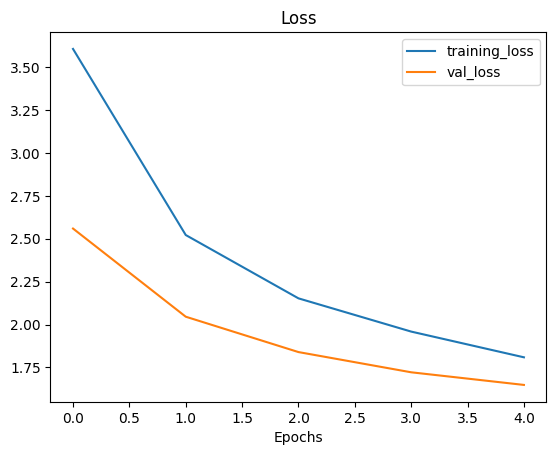

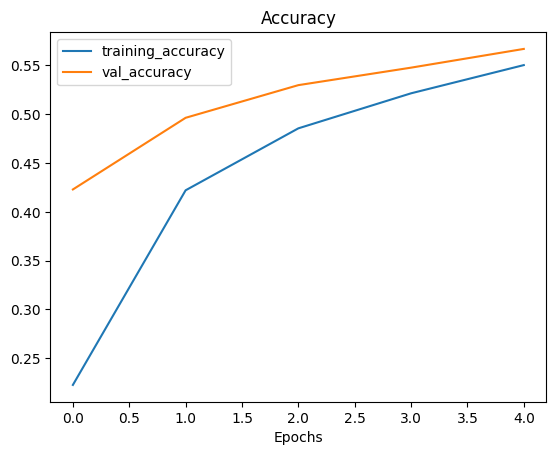

In [ ]:
# Check out our model's training curves
plot_loss_curves(history)

#### Let's fine tune the model by unfreezing the last 5 layers of the base model.

In [ ]:
# Unfreeze all of the layers in the base model
base_model.trainable = True

# Refreeze every layer except for the last 5
for layer in base_model.layers[:-5]:
  layer.trainable = False

In [ ]:
# Recompile model with lower learning rate
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(1e-4), # 10x lower learning rate than default
              metrics=['accuracy'])

In [ ]:
# What layers in the model are trainable?
for layer in model.layers:
  print(layer.name, layer.trainable)

input_layer True
data_augmentation True
efficientnetv2-b0 True
global_average_pooling_layer True
output_layer True


In [ ]:
# Check which layers are trainable
for layer_number, layer in enumerate(base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer False
1 rescaling False
2 normalization False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dwconv2 

In [ ]:
# Fine-tune for 5 more epochs
fine_tune_epochs = 10 # model has already done 5 epochs, this is the total number of epochs we're after (5+5=10)

history_all_classes_10_percent_fine_tune = model.fit(train_data_10_percent,
                                                     epochs=fine_tune_epochs,
                                                     validation_data=test_data_100_percent,
                                                     validation_steps=int(0.15 * len(test_data_100_percent)), # validate on 15% of the test data
                                                     initial_epoch=history.epoch[-1]) # start from previous last epoch

Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 63s 206ms/step - accuracy: 0.5669 - loss: 1.9461 - val_accuracy: 0.5683 - val_loss: 1.7065
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 76s 183ms/step - accuracy: 0.5983 - loss: 1.7718 - val_accuracy: 0.5824 - val_loss: 1.6247
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 175ms/step - accuracy: 0.6169 - loss: 1.6721 - val_accuracy: 0.5890 - val_loss: 1.5673
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 82s 173ms/step - accuracy: 0.6106 - loss: 1.6190 - val_accuracy: 0.6001 - val_loss: 1.5220
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 78s 158ms/step - accuracy: 0.6249 - loss: 1.5602 - val_accuracy: 0.6035 - val_loss: 1.4974
Epoch 10/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 82s 331ms/step - accuracy: 0.6380 - loss: 1.5164 - val_accuracy: 0.6038 - val_loss: 1.4752


In [ ]:
# Evaluate fine-tuned model on the whole test dataset
results_all_classes_10_percent_fine_tune = model.evaluate(test_data_100_percent)
results_all_classes_10_percent_fine_tune

790/790 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.6049 - loss: 1.4772


[1.4796289205551147, 0.6054653525352478]

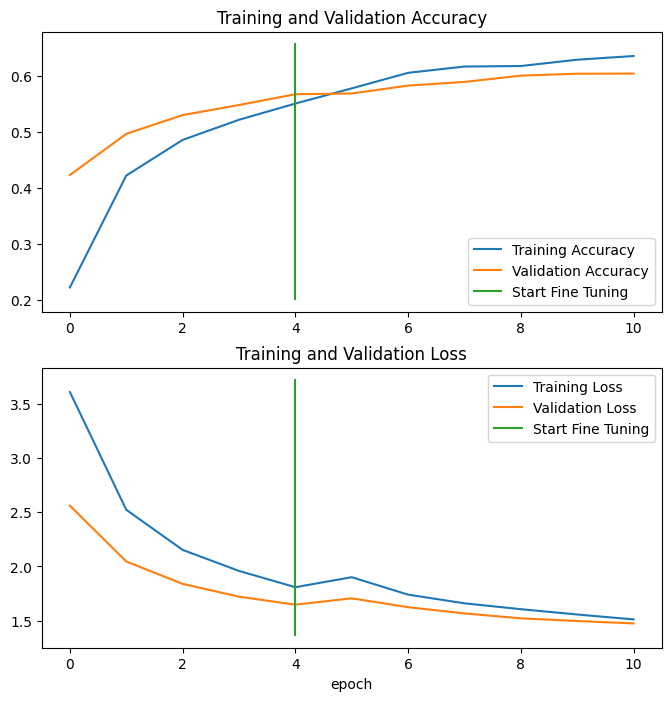

In [ ]:
compare_histories(original_history=history,
                 new_history=history_all_classes_10_percent_fine_tune,
                 initial_epochs=5)

## Saving and Loading the Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Save the fine-tuned model.

In [ ]:
model.save('/content/drive/MyDrive/Colab_Notebooks/TensorFlow Training/TensorFlow Course - Udemy/TensorFlow Models/101_food_classes_10_percent_feature_extraction_model.keras')

#### Let's reload the model....

In [ ]:
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/Colab_Notebooks/TensorFlow Training/TensorFlow Course - Udemy/TensorFlow Models/101_food_classes_10_percent_feature_extraction_model.keras')
loaded_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetv2-b0 (Functional)       │ (None, None, None, 1280)    │       5,919,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling_layer         │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 101)                 │         129,381 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,804,097 (25.96 MB)

 Trainable params: 377,701 (1.44 MB)

 Non-trainable params: 5,670,992 (21.63 MB)

 Optimizer params: 755,404 (2.88 MB)

In [ ]:
loaded_model.evaluate(test_data_100_percent)

790/790 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.6048 - loss: 1.4767


[1.4796286821365356, 0.6054653525352478]

## Making Predictions with the Trained Model

In [ ]:
# Make predictions with model
pred_probs = model.predict(test_data_100_percent, verbose=1) # set verbosity to see how long it will take

790/790 ━━━━━━━━━━━━━━━━━━━━ 58s 69ms/step


In [ ]:
pred_probs[:1], pred_probs.shape

(array([[8.9515081e-05, 4.6258632e-04, 1.1219176e-04, 5.1600427e-06,
         4.8764494e-05, 4.2834250e-05, 4.7616286e-05, 3.3630928e-05,
         2.6095144e-03, 1.1895226e-04, 2.5983358e-05, 4.6795694e-07,
         7.5362797e-05, 2.8781710e-06, 8.6629540e-01, 1.8501420e-06,
         1.0156925e-05, 3.1789953e-03, 3.0431047e-06, 4.6505652e-06,
         4.7670919e-06, 9.1275172e-03, 1.3044984e-03, 6.7497655e-05,
         4.5587321e-06, 3.1806918e-05, 1.6672651e-05, 4.0931587e-05,
         4.5227399e-04, 3.0335935e-03, 1.6029338e-04, 2.9629222e-04,
         1.8826410e-06, 2.1302064e-07, 1.1641718e-05, 5.6067420e-06,
         2.8230759e-04, 4.3830762e-05, 2.1208980e-07, 2.7886234e-05,
         1.0208661e-06, 6.7692978e-05, 2.2860626e-03, 3.1233553e-06,
         1.1908449e-04, 5.1065744e-04, 1.8809355e-05, 4.9119189e-06,
         4.5093052e-06, 1.4715767e-05, 2.2965303e-06, 2.1831364e-07,
         2.8991797e-06, 3.6258327e-05, 1.2585435e-06, 2.0337548e-05,
         1.4051052e-03, 8.1211670e

In [ ]:
# We get one prediction probability per class
print(f"Number of prediction probabilities for sample 0: {len(pred_probs[0])}")
print(f"What prediction probability sample 0 looks like:\n {pred_probs[0]}")
print(f"The class with the highest predicted probability by the model for sample 0: {pred_probs[0].argmax()}")

Number of prediction probabilities for sample 0: 101
What prediction probability sample 0 looks like:
 [8.9515081e-05 4.6258632e-04 1.1219176e-04 5.1600427e-06 4.8764494e-05
 4.2834250e-05 4.7616286e-05 3.3630928e-05 2.6095144e-03 1.1895226e-04
 2.5983358e-05 4.6795694e-07 7.5362797e-05 2.8781710e-06 8.6629540e-01
 1.8501420e-06 1.0156925e-05 3.1789953e-03 3.0431047e-06 4.6505652e-06
 4.7670919e-06 9.1275172e-03 1.3044984e-03 6.7497655e-05 4.5587321e-06
 3.1806918e-05 1.6672651e-05 4.0931587e-05 4.5227399e-04 3.0335935e-03
 1.6029338e-04 2.9629222e-04 1.8826410e-06 2.1302064e-07 1.1641718e-05
 5.6067420e-06 2.8230759e-04 4.3830762e-05 2.1208980e-07 2.7886234e-05
 1.0208661e-06 6.7692978e-05 2.2860626e-03 3.1233553e-06 1.1908449e-04
 5.1065744e-04 1.8809355e-05 4.9119189e-06 4.5093052e-06 1.4715767e-05
 2.2965303e-06 2.1831364e-07 2.8991797e-06 3.6258327e-05 1.2585435e-06
 2.0337548e-05 1.4051052e-03 8.1211670e-05 5.0097873e-04 3.1696516e-04
 1.2426361e-06 1.0769334e-05 1.3571326e-05 8.